
notebook to validate and investigate climate features extracted from CEDA



In [16]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
from project_paths import paths

from src.climate_aggregate import (
    ADDITIVE_METRICS,
    ANNUAL_COUNT_METRICS,
    ANNUAL_EXTREME_METRICS,
    METRIC_GROUP,
    WINDOWS,
    window_label,
)
from src.features import prepare_features

features = pl.read_parquet(paths.processed_data / "climate_features.parquet")
unified = pl.read_parquet(paths.unified_file)
scope = prepare_features(unified)

WINDOW_LABELS = [window_label(w) for w in WINDOWS]
features.shape


(23304, 151)

## validity checks

Column set matches the emitted contract, check dtypes, check for NaNs and nulls, check for invalid negatives, check that count increases across a window within a metric

In [17]:
expected_cols = {"asset_id", "climate__oncoast_fallback", "climate__ceiling_lag_days"}
expected_cols |= {f"climate__{label}__window_truncated" for label in WINDOW_LABELS}
for metric in ADDITIVE_METRICS:
    for label in WINDOW_LABELS:
        expected_cols |= {f"climate__{metric}__{label}__{stat}" for stat in ("count", "rate", "max_in_year", "z")}
for metric in ANNUAL_EXTREME_METRICS:
    for label in WINDOW_LABELS:
        expected_cols |= {f"climate__{metric}__{label}__{stat}" for stat in ("mean", "max")}
for metric in ANNUAL_COUNT_METRICS:
    for label in WINDOW_LABELS:
        expected_cols |= {f"climate__{metric}__{label}__{stat}" for stat in ("sum", "mean", "max")}

missing = expected_cols - set(features.columns)
extra = set(features.columns) - expected_cols
print("missing:", missing)
print("extra:", extra)
assert not missing and not extra


missing: set()
extra: set()


In [18]:
# dtypes -  all numeric, no categoricals
schema = features.schema
non_numeric = {c: t for c, t in schema.items() if not (t.is_numeric() or t == pl.Boolean)}
print("non-numeric columns (should be empty):", non_numeric)

# negatives on count/sum columns
count_like = [c for c in features.columns if c.endswith(("__count", "__sum"))]
neg = {c: features.select((pl.col(c) < 0).sum()).item() for c in count_like}
print("columns with negative values:", {c: n for c, n in neg.items() if n > 0})


non-numeric columns (should be empty): {}
columns with negative values: {}


In [19]:
# count should not be decreasing 2y -> 5y -> 15y -> 30y within a metric
violations = {}
for metric in ADDITIVE_METRICS:
    for small, large in zip(WINDOW_LABELS, WINDOW_LABELS[1:]):
        s, l = features[f"climate__{metric}__{small}__count"], features[f"climate__{metric}__{large}__count"]
        both = s.is_not_null() & l.is_not_null()
        bad = (l.filter(both) < s.filter(both)).sum()
        if bad:
            violations[f"{metric}: {small}->{large}"] = bad
violations


{}

## coverage / distribution



In [20]:
for metric in ADDITIVE_METRICS:
    col = f"climate__{metric}__5y__rate"
    vals = features[col].drop_nulls()

    print(
        f"{metric:12s} n={vals.len():6d} zero_frac={float((vals == 0).mean()):.3f} mean={float(vals.mean()):.3f} p95={float(vals.quantile(0.95)):.3f}"
    )


ftc          n= 23288 zero_frac=0.001 mean=30.080 p95=41.606
fdd          n= 23288 zero_frac=0.022 mean=5.234 p95=10.289
drydays      n= 23288 zero_frac=0.000 mean=235.443 p95=258.835
r10mm        n= 23288 zero_frac=0.000 mean=20.797 p95=40.005
r20mm        n= 23288 zero_frac=0.001 mean=4.507 p95=10.401


In [21]:
print("oncoast_fallback rate:", float(features['climate__oncoast_fallback'].mean()))
print(features['climate__ceiling_lag_days'].describe())

for label in WINDOW_LABELS:
    print(label, "window_truncated rate:", float(features[f'climate__{label}__window_truncated'].mean()))


oncoast_fallback rate: 0.012100926879505664
shape: (9, 2)
┌────────────┬─────────┐
│ statistic  ┆ value   │
│ ---        ┆ ---     │
│ str        ┆ f64     │
╞════════════╪═════════╡
│ count      ┆ 23303.0 │
│ null_count ┆ 1.0     │
│ mean       ┆ 0.0     │
│ std        ┆ 0.0     │
│ min        ┆ 0.0     │
│ 25%        ┆ 0.0     │
│ 50%        ┆ 0.0     │
│ 75%        ┆ 0.0     │
│ max        ┆ 0.0     │
└────────────┴─────────┘
2y window_truncated rate: 0.006951894605844741
5y window_truncated rate: 0.02119898725485989
15y window_truncated rate: 0.099000128738789
30y window_truncated rate: 0.24700682315581685


## Redundancy

Spearman/Pearson correlation across metric x window x stat
use results to find features that should be selected / could be discarded
Specifically test `rewet_15` vs `dryspell_count_15`, and each `z` variant vs its parent `rate`

In [22]:
candidate_cols = [c for c in features.columns if c.startswith("climate__") and features.schema[c].is_numeric()]
corr_df = features.select(candidate_cols).drop_nulls()
corr = corr_df.to_pandas().corr(method="spearman")
corr.shape


(145, 145)

In [23]:
# rewet_15 vs dryspell_count_15 - designed to be distinct, check they're not near-collinear
for label in WINDOW_LABELS:
    a = features[f"climate__rewet_15__{label}__sum"]
    b = features[f"climate__dryspell_count_15__{label}__sum"]
    both = a.is_not_null() & b.is_not_null()
    r = np.corrcoef(a.filter(both).to_numpy(), b.filter(both).to_numpy())[0, 1]
    print(f"{label}: rewet_15 vs dryspell_count_15 pearson r = {r:.3f}")


2y: rewet_15 vs dryspell_count_15 pearson r = 0.623
5y: rewet_15 vs dryspell_count_15 pearson r = 0.571
15y: rewet_15 vs dryspell_count_15 pearson r = 0.703
30y: rewet_15 vs dryspell_count_15 pearson r = 0.819


In [24]:
# z vs rate - z is designed to remove the spatial mean, so should not be ~1 correlated with rate
for metric in ADDITIVE_METRICS:
    label = "30y"
    a = features[f"climate__{metric}__{label}__rate"]
    b = features[f"climate__{metric}__{label}__z"]
    both = a.is_not_null() & b.is_not_null()
    if both.sum() > 1:
        r = np.corrcoef(a.filter(both).to_numpy(), b.filter(both).to_numpy())[0, 1]
        print(f"{metric} ({label}): rate vs z pearson r = {r:.3f}")


ftc (30y): rate vs z pearson r = 0.075
fdd (30y): rate vs z pearson r = 0.427
drydays (30y): rate vs z pearson r = 0.113
r10mm (30y): rate vs z pearson r = 0.186
r20mm (30y): rate vs z pearson r = 0.370


## Grade split

Mean grade and grade >= 4 percentage by feature decile, overall and within the four largest asset subtypes (following the nb14 method). 

Select a small candidate set and hand off to the experiment

In [25]:
joined = (
    scope.select("asset_id", "condition_grade", "aims__asset_sub_type")
    .join(features, on="asset_id", how="left")
)
joined.shape


(23304, 153)

In [26]:
joined.columns

['asset_id',
 'condition_grade',
 'aims__asset_sub_type',
 'climate__ftc__2y__count',
 'climate__ftc__2y__rate',
 'climate__ftc__2y__max_in_year',
 'climate__ftc__2y__z',
 'climate__fdd__2y__count',
 'climate__fdd__2y__rate',
 'climate__fdd__2y__max_in_year',
 'climate__fdd__2y__z',
 'climate__drydays__2y__count',
 'climate__drydays__2y__rate',
 'climate__drydays__2y__max_in_year',
 'climate__drydays__2y__z',
 'climate__r10mm__2y__count',
 'climate__r10mm__2y__rate',
 'climate__r10mm__2y__max_in_year',
 'climate__r10mm__2y__z',
 'climate__r20mm__2y__count',
 'climate__r20mm__2y__rate',
 'climate__r20mm__2y__max_in_year',
 'climate__r20mm__2y__z',
 'climate__dryspell_max__2y__mean',
 'climate__dryspell_max__2y__max',
 'climate__rain_max_day__2y__mean',
 'climate__rain_max_day__2y__max',
 'climate__dryspell_count_10__2y__sum',
 'climate__dryspell_count_10__2y__mean',
 'climate__dryspell_count_10__2y__max',
 'climate__dryspell_count_15__2y__sum',
 'climate__dryspell_count_15__2y__mean',
 

In [29]:
def decile_split(df: pl.DataFrame, col: str, n_bins: int = 10) -> pl.DataFrame:
    d = df.select("condition_grade", col).drop_nulls()
    if d.height < n_bins:
        return pl.DataFrame()
    return (
        d.with_columns(pl.col(col).qcut(n_bins, labels=[str(i) for i in range(n_bins)], allow_duplicates=True).alias("decile"))
        .group_by("decile")
        .agg(
            pl.len().alias("n"),
            pl.col("condition_grade").mean().alias("mean_grade"),
            (pl.col("condition_grade") >= 4).mean().alias("pct_ge4"),
        )
        .sort("decile")
    )

# swap in cols that have survived based on the redundancy check above

dcol = "climate__ftc__5y__rate"
decile_split(joined, dcol)


decile,n,mean_grade,pct_ge4
cat,u32,f64,f64
"""0""",2345,2.794456,0.086567
"""1""",2399,2.760734,0.089621
"""2""",2275,2.81011,0.114286
"""3""",2383,2.788082,0.086865
"""4""",2506,2.747406,0.081405
"""5""",2155,2.881671,0.113225
"""6""",2332,2.799743,0.09434
"""7""",2470,2.857085,0.124291
"""8""",2211,2.809136,0.088195


In [30]:
dcol = "climate__rewet_15__2y__mean"
decile_split(joined, dcol)

decile,n,mean_grade,pct_ge4
cat,u32,f64,f64
"""0""",5745,2.716449,0.071366
"""2""",10141,2.852579,0.109259
"""6""",5164,2.775174,0.099923
"""9""",2153,2.813284,0.094287


In [31]:
dcol = "climate__r20mm__5y__z"
decile_split(joined, dcol)

decile,n,mean_grade,pct_ge4
cat,u32,f64,f64
"""0""",2332,2.758148,0.106775
"""1""",2328,2.777491,0.10567
"""2""",2366,2.807692,0.112003
"""3""",2292,2.801483,0.099476
"""4""",2372,2.838533,0.109191
"""5""",2283,2.801139,0.098993
"""6""",2328,2.805412,0.097509
"""7""",2329,2.784886,0.083298
"""8""",2331,2.772201,0.07293


In [ ]:
def decile_split_by_subtype(
    df: pl.DataFrame, 
    col: str, 
    subtypes: list, 
    n_bins: int = 10
) -> pl.DataFrame:
    
    """
    decile split within each subtype
    deciles are relative to that subtypes own distribution 
    skips a subtype when qcut can't form n_bins distinct edges rather than erroring out the whole op
    """

    out = []

    for subtype in subtypes:

        sub = df.filter(pl.col("aims__asset_sub_type") == subtype)

        try:
            tab = decile_split(sub, col, n_bins=n_bins)
        except Exception as e: # polars qcut raises on duplicate quantile edges
            print(f"skipped {subtype}: {type(e).__name__}")
            continue

        if tab.height:
            out.append(tab.with_columns(pl.lit(subtype).alias("subtype")))
            
    return pl.concat(out) if out else pl.DataFrame()

In [ ]:
def rho(frame: pl.DataFrame, col) -> float | None:
    d = frame.select("condition_grade", col).drop_nulls()
    if d.height < 3:
        return None
    return d.select(
        pl.corr("condition_grade", col, method="spearman")
    ).item()


def within_subtype_signal(
    df: pl.DataFrame, 
    col: str, 
    subtypes: list,
) -> pl.DataFrame:

    rows = [{"subtype": "ALL", "n": df.select(col).drop_nulls().height, "spearman_grade": rho(df, col)}]
    for st in subtypes:
        sub = df.filter(pl.col("aims__asset_sub_type") == st)
        rows.append({"subtype": st, "n": sub.select(col).drop_nulls().height, "spearman_grade": rho(sub, col)})
    return pl.DataFrame(rows)


subtypes = joined.get_column("aims__asset_sub_type").unique().to_list() 

from functools import partial

within_subtype = partial(within_subtype_signal, df=joined, subtypes=subtypes)



In [36]:
col = "climate__ftc__5y__rate"

spearmans_scores = within_subtype(col=col)

with pl.Config(tbl_rows=-1):
    print(spearmans_scores)

shape: (15, 3)
┌────────────────────────┬───────┬────────────────┐
│ subtype                ┆ n     ┆ spearman_grade │
│ ---                    ┆ ---   ┆ ---            │
│ str                    ┆ i64   ┆ f64            │
╞════════════════════════╪═══════╪════════════════╡
│ ALL                    ┆ 23288 ┆ -0.006076      │
│ Barrier Beach          ┆ 4     ┆ -0.544331      │
│ Beach                  ┆ 97    ┆ -0.29327       │
│ Bridge Abutment        ┆ 109   ┆ -0.141606      │
│ Cliff                  ┆ 1     ┆ null           │
│ Demountable Defence    ┆ 374   ┆ -0.167204      │
│ Dunes                  ┆ 70    ┆ 0.148726       │
│ Embankment             ┆ 12269 ┆ -0.031175      │
│ Engineered High Ground ┆ 3070  ┆ -0.071648      │
│ Flood Gate             ┆ 1381  ┆ -0.126796      │
│ Promenade              ┆ 1     ┆ null           │
│ Quay                   ┆ 10    ┆ 0.105736       │
│ Spillway               ┆ 114   ┆ -0.081531      │
│ Wall                   ┆ 5786  ┆ -0.025242     

In [38]:
# use the matrix of correlations to inspect which features 
# create several heatmaps to visualise
# 

import seaborn as sns

WIN_ORDER = {"2y": 0, "5y": 1, "15y": 2, "30y": 3}



def parse_col(c):
    p = c.split("__")
    return (p[1], p[2], p[3]) if len(p) == 4 else None

def order_cols(cols):
    return sorted(cols, key=lambda c: (parse_col(c)[0], WIN_ORDER[parse_col(c)[1]], parse_col(c)[2]))

def plot_heatmap(cols, title, annot=False, figsize=(10, 8)):

    cols = order_cols(cols)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr.loc[cols, cols], 
        vmin=-1, 
        vmax=1, 
        cmap="RdBu_r", 
        center=0,
        square=True, 
        annot=annot, 
        fmt=".2f", 
        linewidths=0.3,
        cbar_kws={"shrink": 0.6}
    )

    plt.title(title); plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
    plt.tight_layout(); plt.show()


corr_cols = [
    c for c in features.columns
    if c.startswith("climate__")
    and features.schema[c].is_numeric()
    and parse_col(c) is not None
    and features[c].n_unique() > 1 # drop ceiling_lag (zero variance)
]

corr = features.select(corr_cols).to_pandas().corr(method="spearman")


len(corr_cols)

144

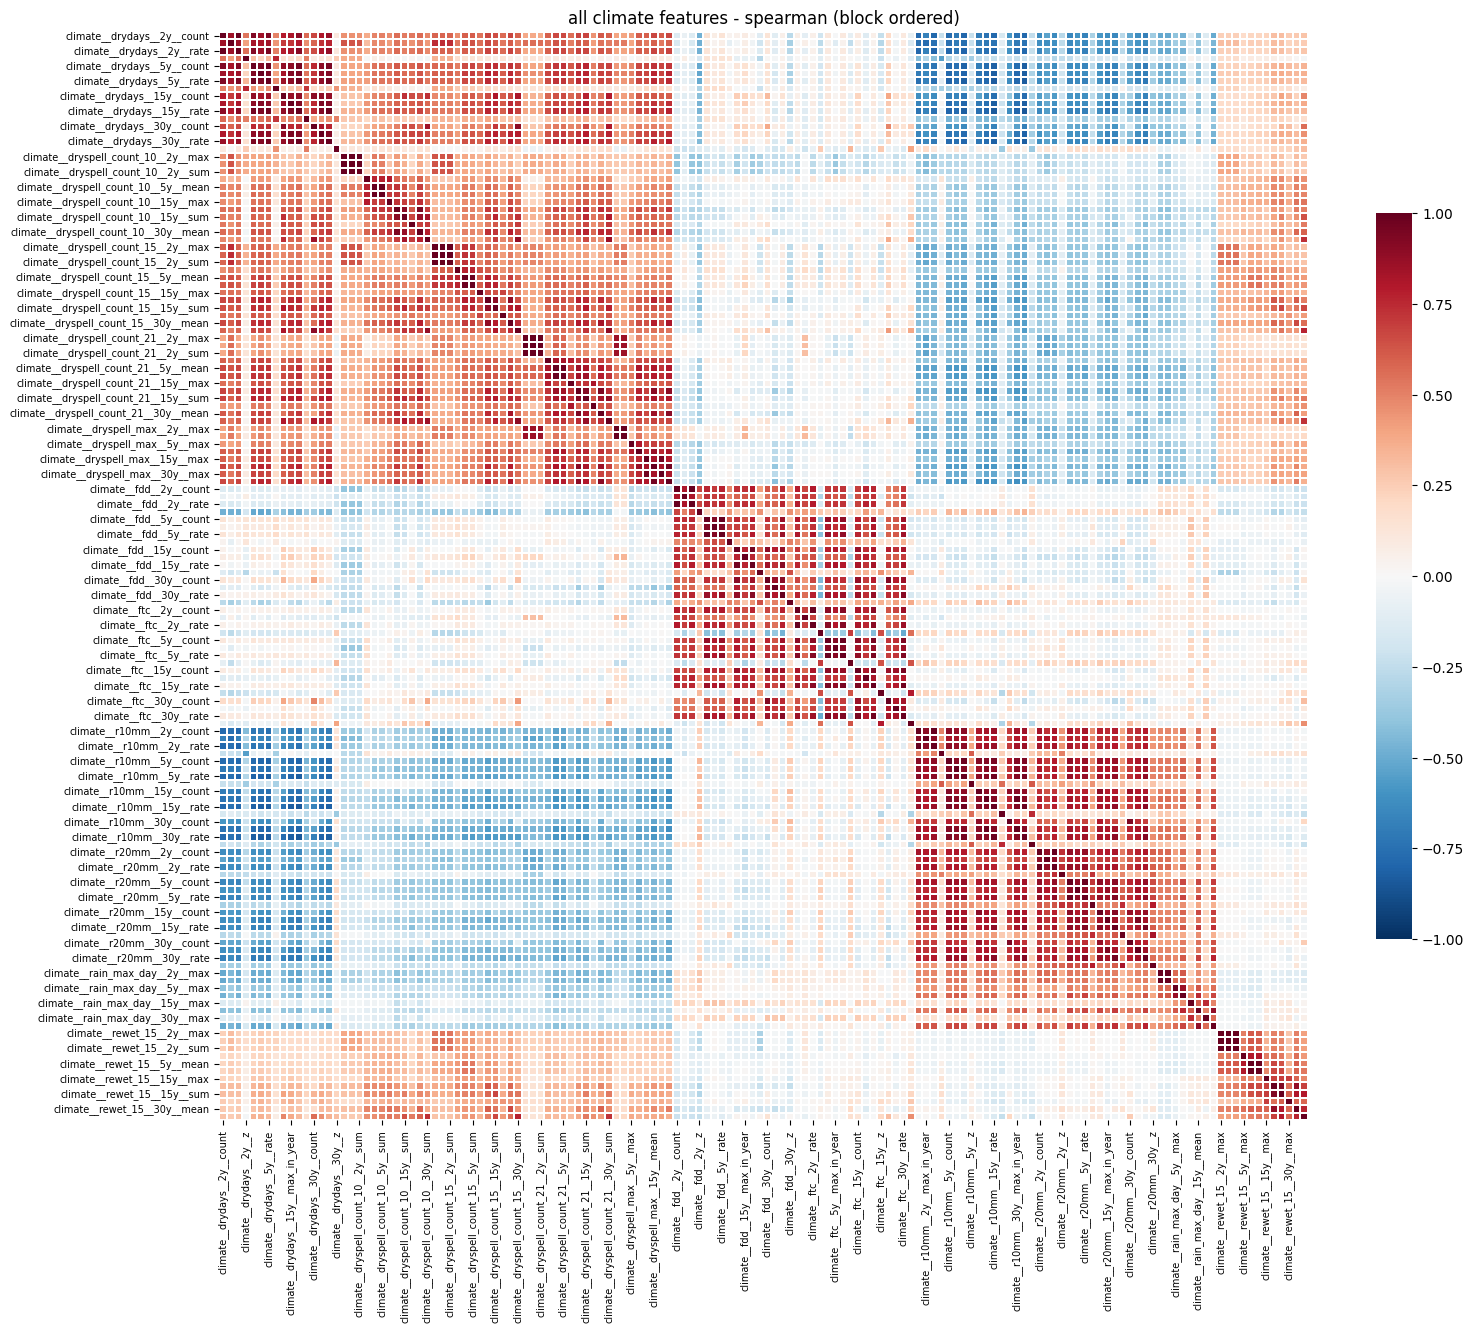

In [39]:
# 1 - full grid

plot_heatmap(corr_cols, "all climate features - spearman (block ordered)", figsize=(16, 14))

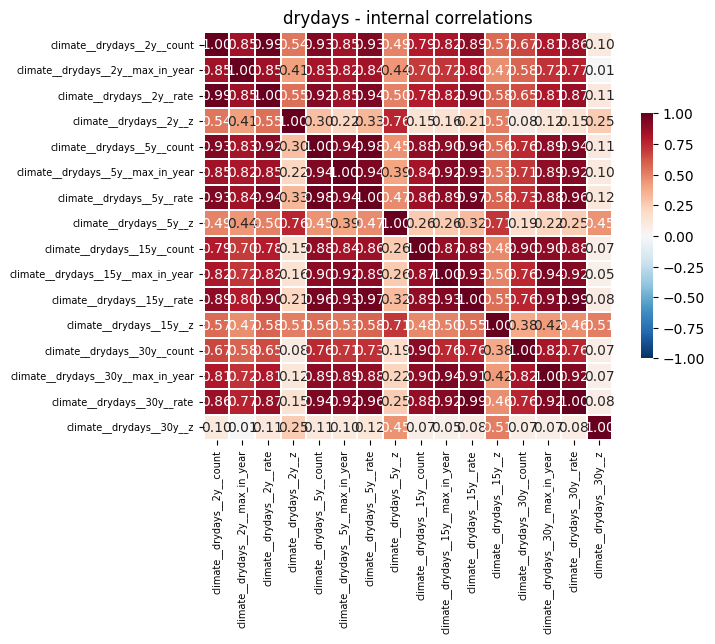

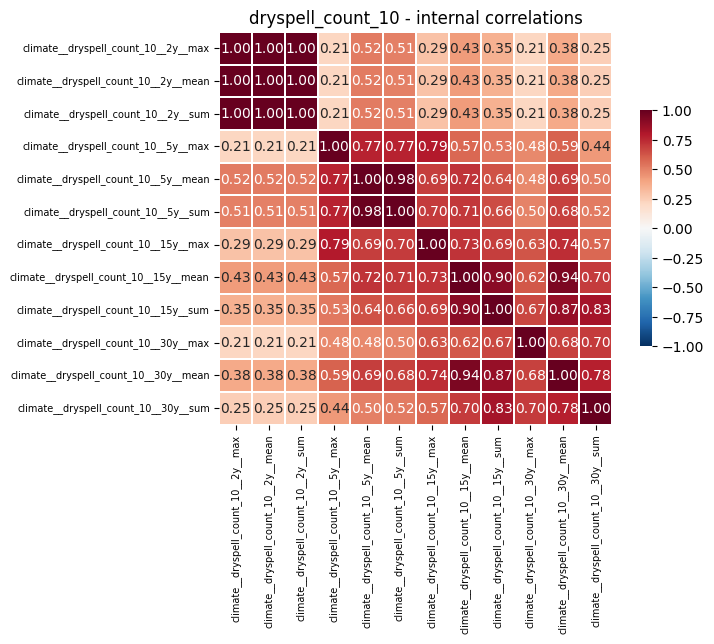

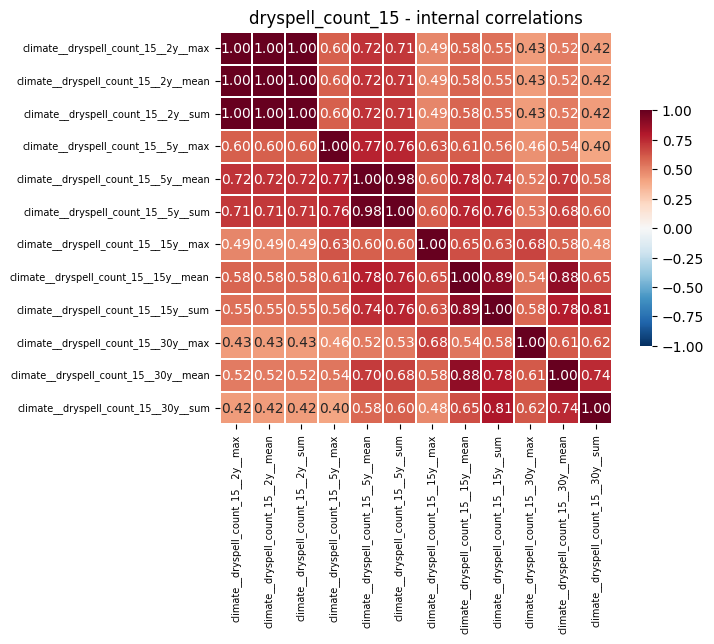

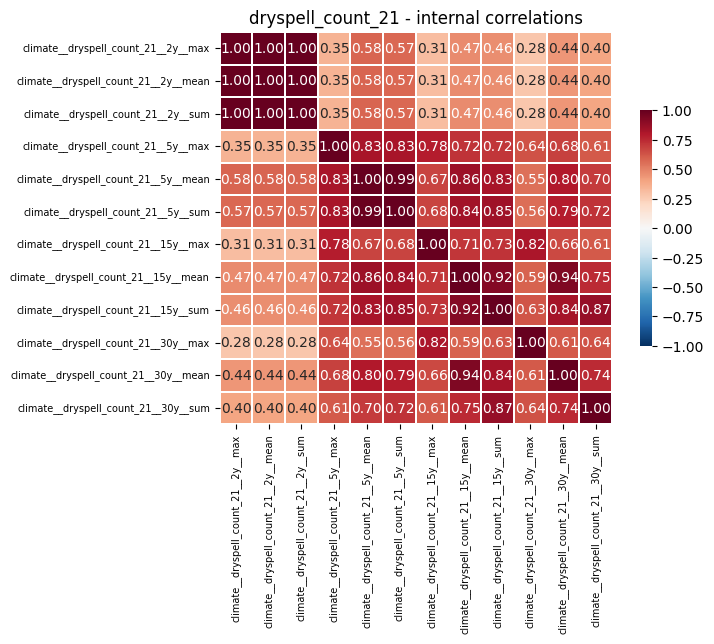

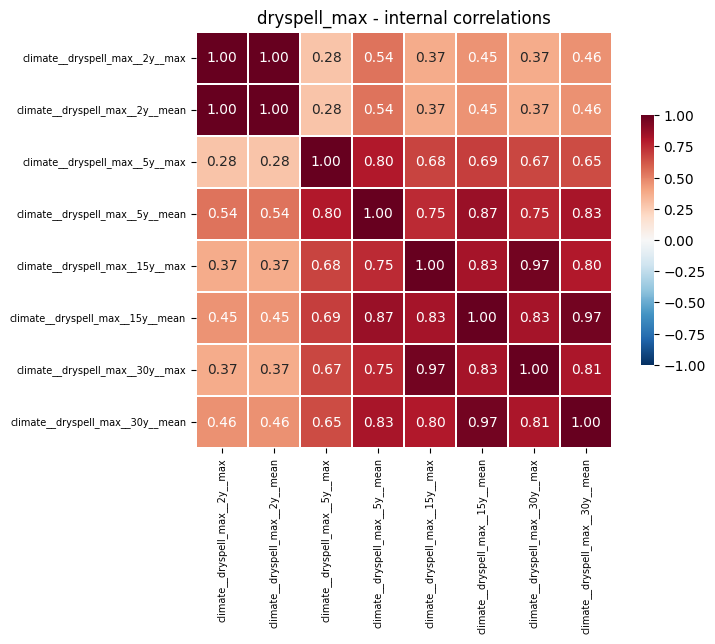

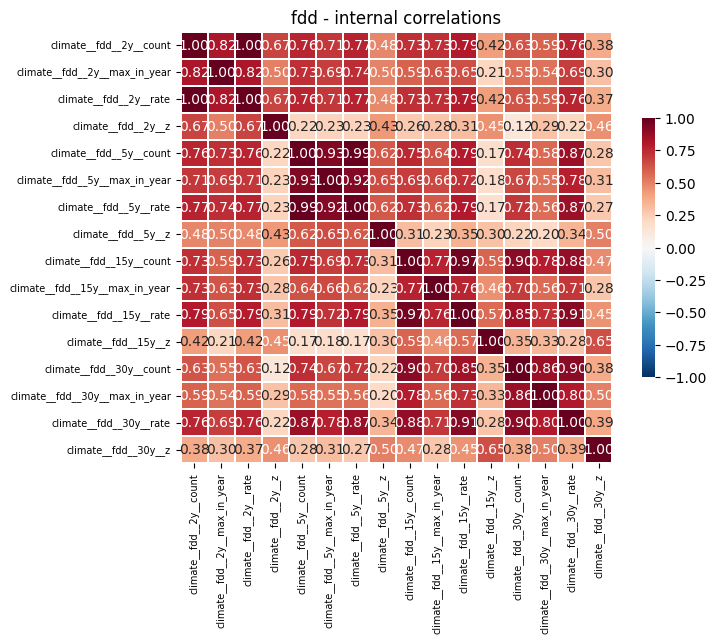

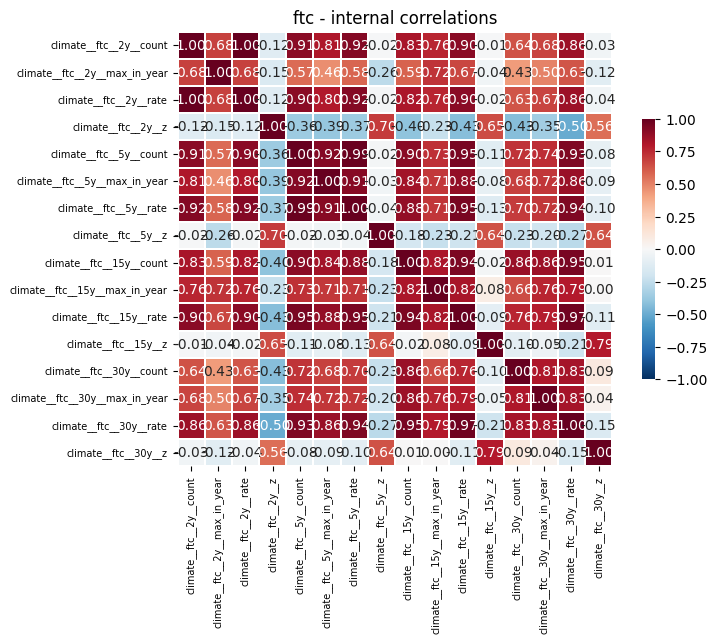

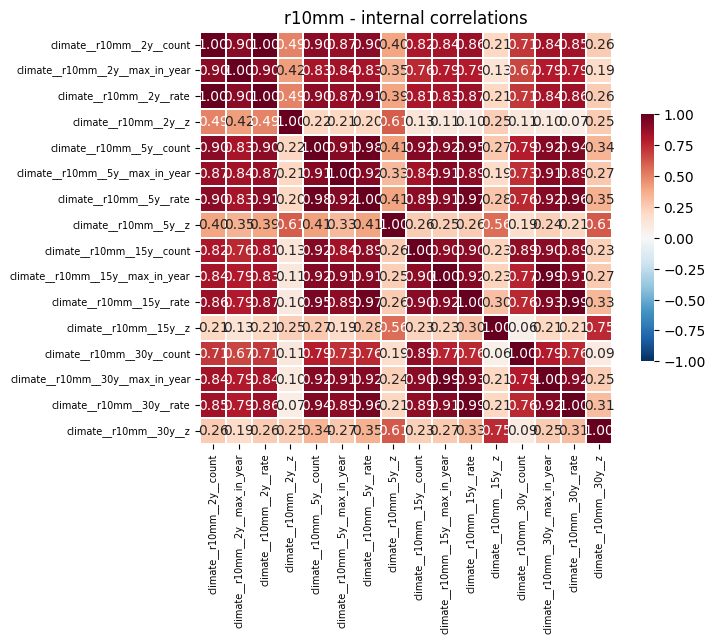

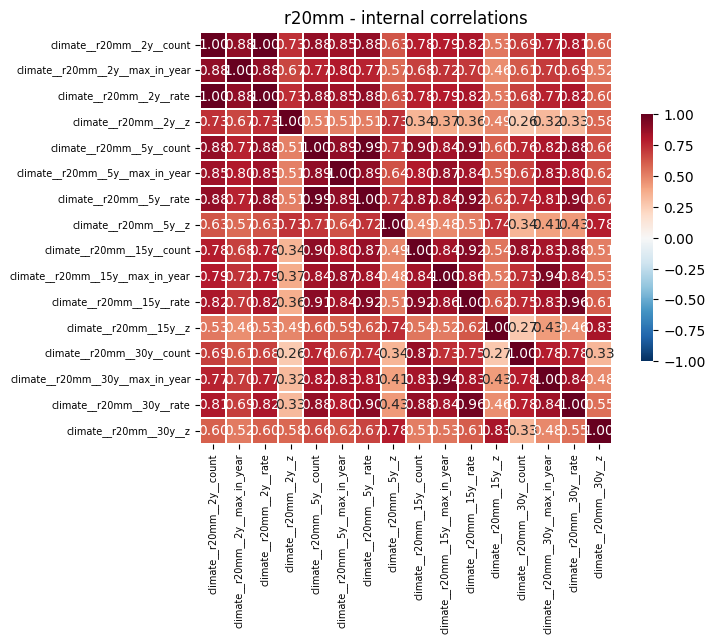

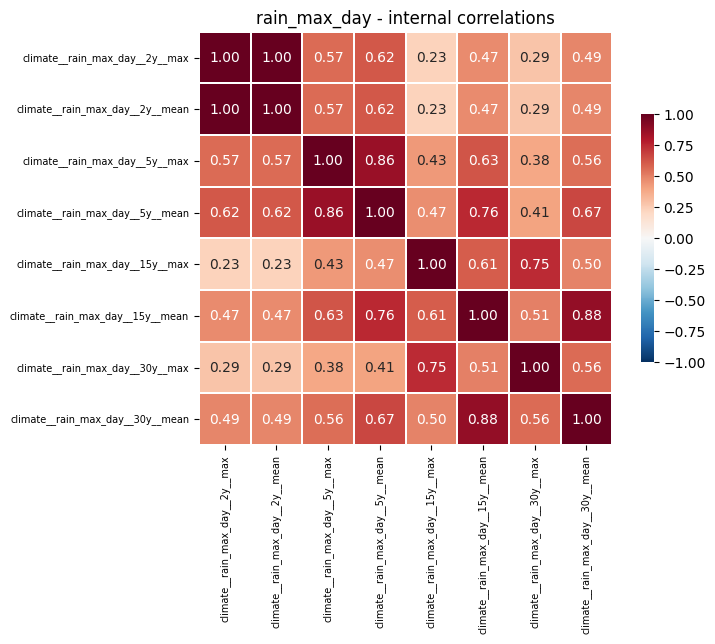

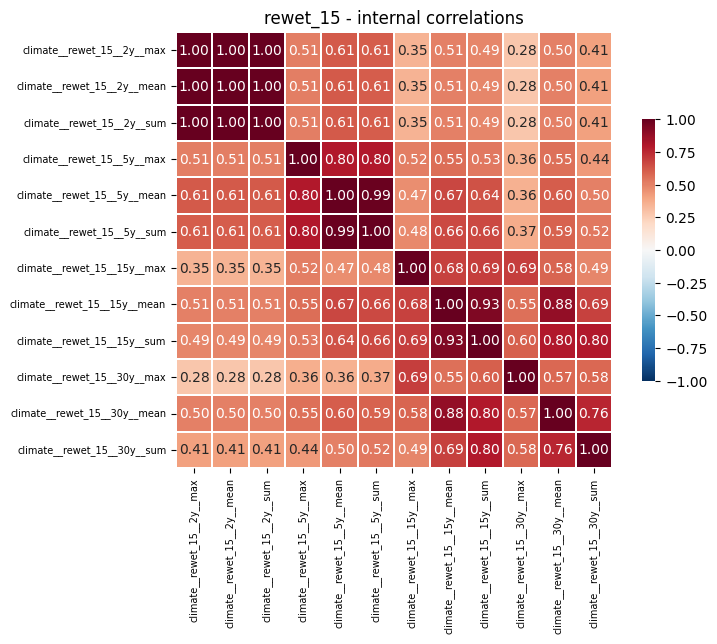

In [40]:
# 2 - within each metric
# to decide which stat and which time window to choose per mechanism

for metric in sorted({parse_col(c)[0] for c in corr_cols}):
    cols = [c for c in corr_cols if parse_col(c)[0] == metric]
    plot_heatmap(cols, f"{metric} - internal correlations", annot=True, figsize=(8, 6.5))

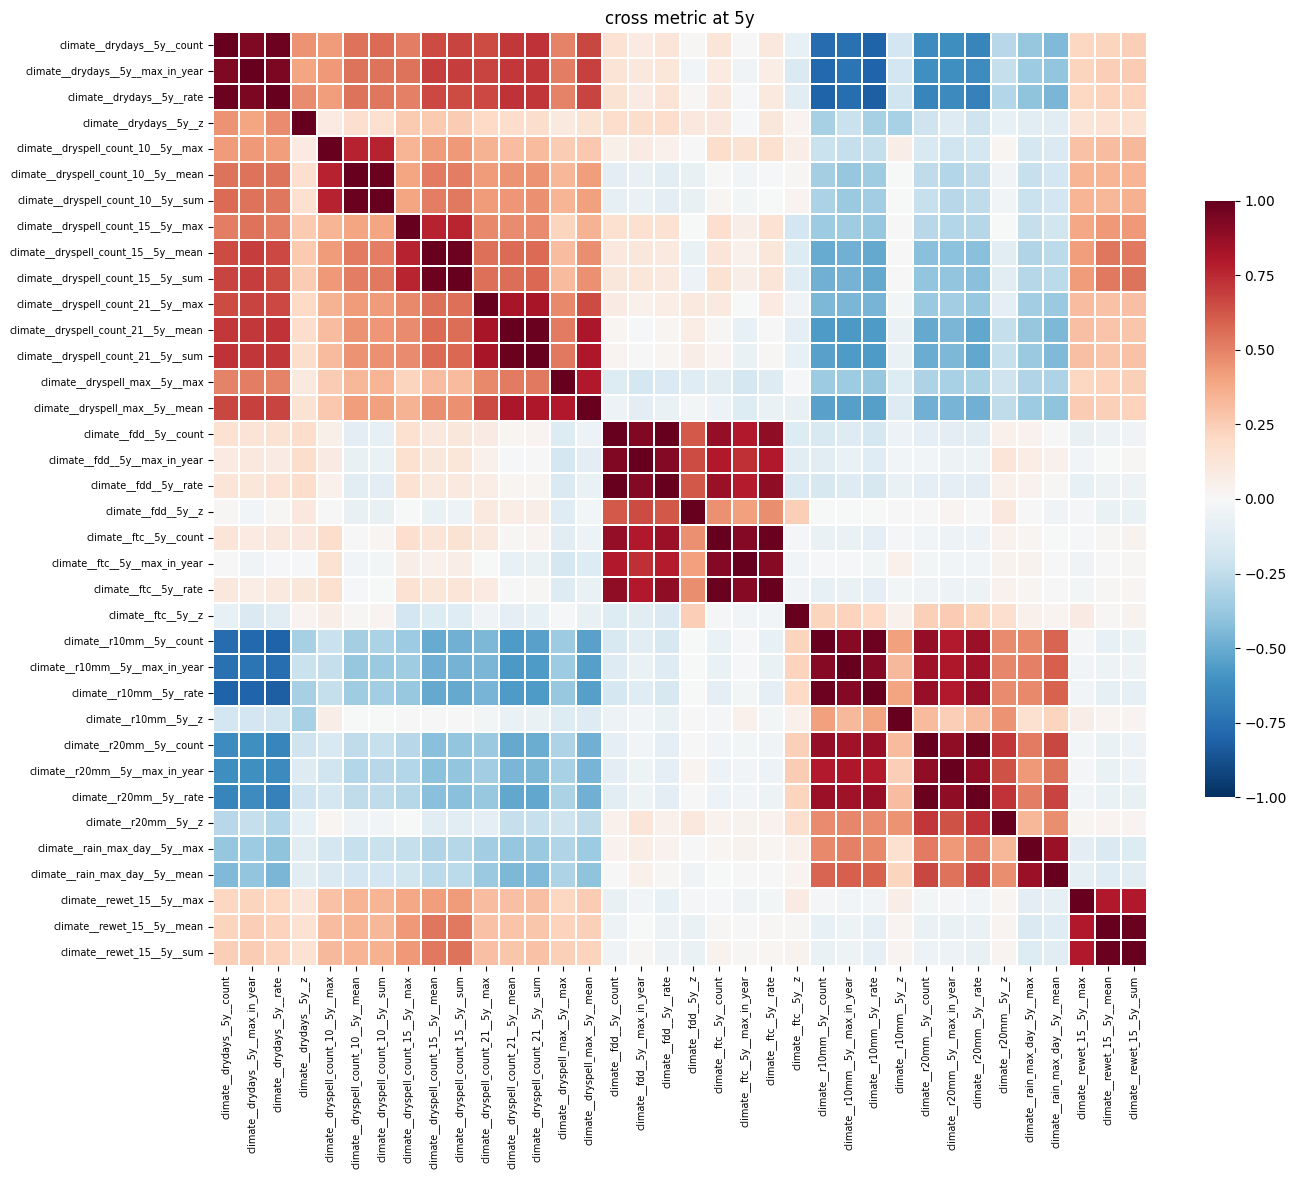

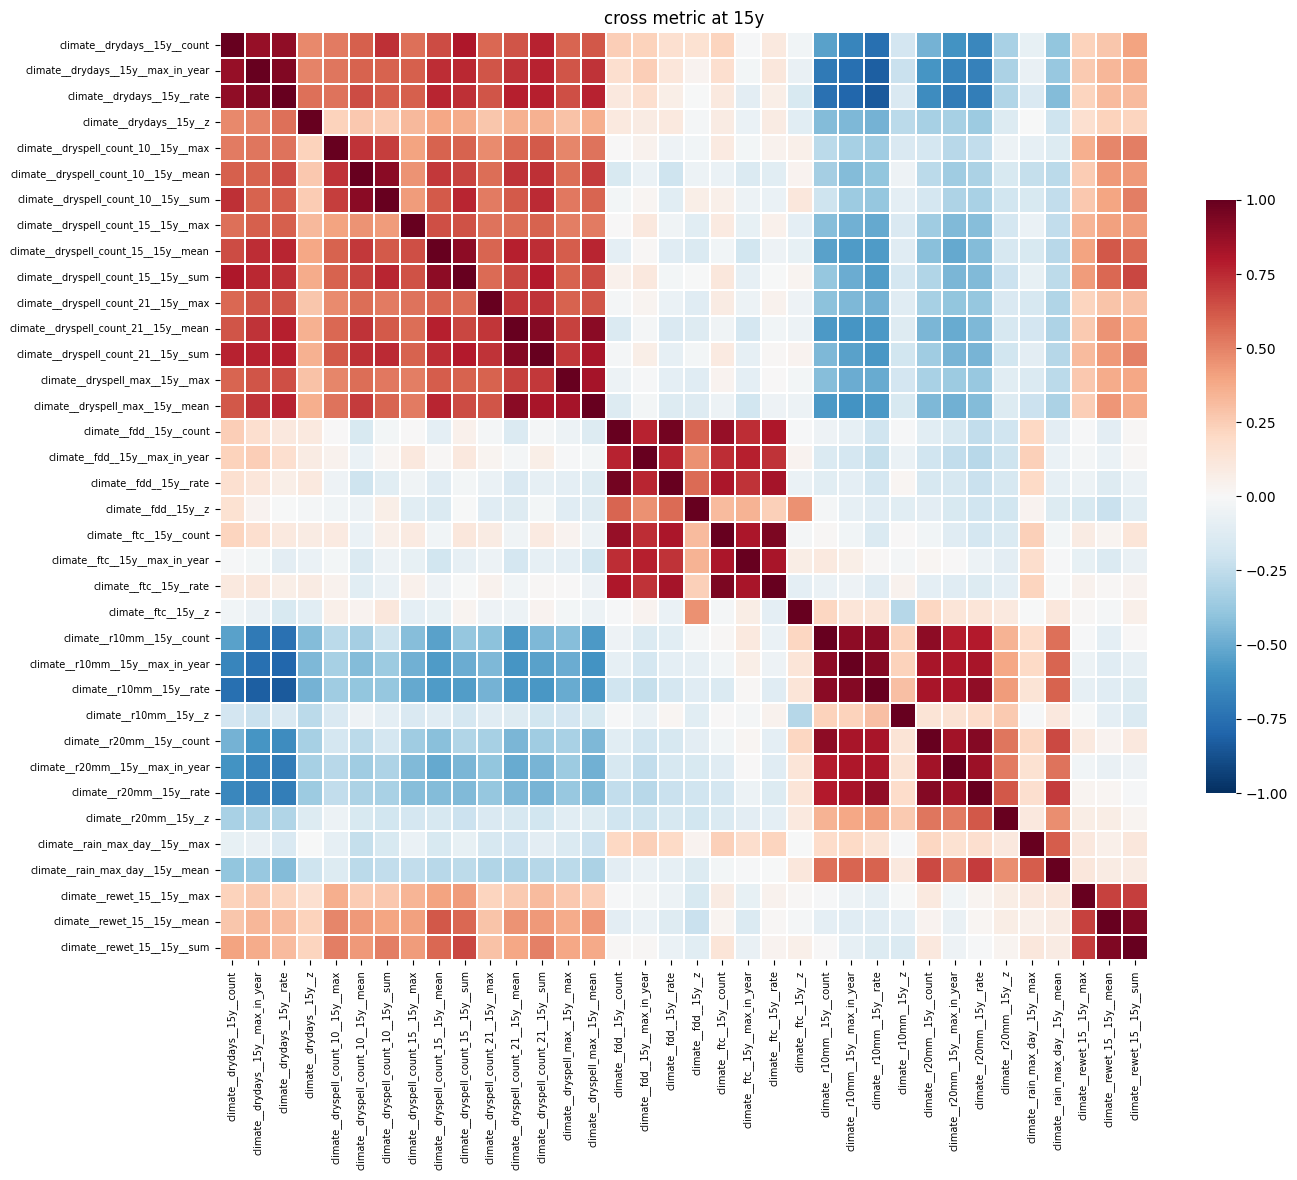

In [42]:
# 3 - cross metric for fixed windows

for window in ["5y", "15y"]:
    cols = [c for c in corr_cols if parse_col(c)[1] == window]
    plot_heatmap(cols, f"cross metric at {window}", figsize=(14, 12))

so the first heatmap shows that some of the metrics are correlated - as expected, r10, r20, and dry days all have some correlation. r10 and r20 obviously have a strong positive correlation, and obviously the more dry days then the lower the value for r10/r20. Its likely that I will only select one of these, and possibly also include dryspell in the group, to provide a signal that represents how wet/arid the climate in that cell is.

freeze thaw cycle is one that has little correlation with the other metrics and so is a good candidate to include.

By using different stats and windows, I may be able to increase the total number of features selected without introducing ones that correlate.

Obviously, this information is only sufficient so far to exclude combinations with high correlations. The important piece of information to get next is correlation with grade, or some other indication of how much predictive power each has (maybe shift in distribution of grades in the metric), and this will guide which features are actually worth selecting and including to train a model.

I can bare in mind that HGB is fairly tolerant of correlated features. Its more about making sure I can keep the number of features as low as possible while adding signal in, since adding a feature with low signal can decrease the performance, and definitely make the SHAP/featue importances harder to interpret. 


next, im going to borrow the approach from lidar features notebook (nb18) where i used a average precision on using the correlation to predict the grade as a way to get a score for how much skill a single feature model would have (kinda). 


In [43]:
# keeping n boot = 1000 means this function is probably going to take 10 mins + to run for all features

from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score


def target_stats(frame, feat, n_boot=1000, seed=0):

    s = frame.select(feat, "condition_grade").drop_nulls()
    x = s[feat].to_numpy()
    y = s["condition_grade"].to_numpy()

    if len(x) < 30 or np.unique(x).size < 3:
        return None
    
    rho = spearmanr(x, y).statistic

    ybin = (y >= 4).astype(int)
    prev = float(ybin.mean())

    # avg_precision = average_precision_score(ybin, x * (np.sign(rho)))

    avg_precision = (
        average_precision_score(ybin, x * (np.sign(rho) or 1.0))
        if 0 < ybin.sum() < len(ybin) else float("nan")
    )

    rng = np.random.default_rng(seed)
    boot = np.array(
        [spearmanr(x[i], y[i]).statistic for i in (rng.integers(0, len(x), len(x)) for _ in range(n_boot))]
    )

    low, high = np.nanpercentile(boot, [2.5, 97.5])

    # adding decile lift, helps catch if increase is not monotone catch
    dec = decile_split(frame, feat)
    decile_peak_lift = (
        dec.get_column("pct_ge4").max() / prev if dec.height and prev else None
    )

    result = {
        "feature": feat.replace("lidar__crest_", ""),
        "n": len(x),
        "rho": round(rho, 4),
        "rho_low": round(low, 4),
        "rho_high": round(high, 4),
        "average_precision": round(avg_precision, 5),
        "previous": round(prev, 5),
        "average_precision_increase": (round(avg_precision / prev, 4) if prev else None),
        "decile_peak_lift": decile_peak_lift,
        "confidence_int_exludes_0": (low > 0 or high < 0)
    }

    return result



In [44]:
columns = [
    col for col in joined.columns 
    if col.startswith("climate__") and joined.schema[col].is_numeric()
]

stats = [target_stats(joined, col) for col in columns]

df_stats = pl.DataFrame(stats)

df_stats

feature,n,rho,rho_low,rho_high,average_precision,previous,average_precision_increase,decile_peak_lift,confidence_int_exludes_0
str,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""climate__ftc__2y__count""",23288,-0.0211,-0.034,-0.0073,0.09518,0.09619,0.9896,1.267374,1.0
"""climate__ftc__2y__rate""",23288,-0.0233,-0.0357,-0.0097,0.09539,0.09619,0.9917,1.269583,1.0
"""climate__ftc__2y__max_in_year""",23203,-0.0126,-0.0251,0.0001,0.10097,0.09641,1.0473,1.148964,0.0
"""climate__ftc__2y__z""",23288,-0.0234,-0.0369,-0.0122,0.10733,0.09619,1.1158,1.236817,1.0
"""climate__fdd__2y__count""",23288,-0.0288,-0.0421,-0.0164,0.10079,0.09619,1.0479,1.242031,1.0
…,…,…,…,…,…,…,…,…,…
"""climate__dryspell_count_21__30…",23203,0.0529,0.0399,0.0663,0.10319,0.09641,1.0703,1.127664,1.0
"""climate__rewet_15__30y__sum""",23203,0.1371,0.1248,0.1495,0.1108,0.09641,1.1492,1.472858,1.0
"""climate__rewet_15__30y__mean""",23203,-0.0054,-0.0185,0.0069,0.09227,0.09641,0.9571,1.297621,0.0


In [50]:
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_stats.sort(by=pl.col("rho").abs(), descending=True))

shape: (145, 10)
┌──────────┬───────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ feature  ┆ n     ┆ rho     ┆ rho_low ┆ rho_hig ┆ average ┆ previou ┆ average ┆ decile_ ┆ confide │
│ ---      ┆ ---   ┆ ---     ┆ ---     ┆ h       ┆ _precis ┆ s       ┆ _precis ┆ peak_li ┆ nce_int │
│ str      ┆ i64   ┆ f64     ┆ f64     ┆ ---     ┆ ion     ┆ ---     ┆ ion_inc ┆ ft      ┆ _exlude │
│          ┆       ┆         ┆         ┆ f64     ┆ ---     ┆ f64     ┆ rease   ┆ ---     ┆ s_0     │
│          ┆       ┆         ┆         ┆         ┆ f64     ┆         ┆ ---     ┆ f64     ┆ ---     │
│          ┆       ┆         ┆         ┆         ┆         ┆         ┆ f64     ┆         ┆ f64     │
╞══════════╪═══════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╡
│ null     ┆ null  ┆ null    ┆ null    ┆ null    ┆ null    ┆ null    ┆ null    ┆ null    ┆ null    │
│ climate_ ┆ 23288 ┆ 0.1963  ┆ 0.1835  ┆ 0.2094  ┆ 0.12791 ┆ 0.09619 ┆ 1.3

i think this shows overall that i shouldnt be confident of getting good predictive signal out of this group of features.

next, largely the 30 year windows get the highest scores and this decreases as the window shortens down to 2 and 5 years having the lowest scores.

I think that the longer the window, the more the stat becomes about the average climate in the location and not about specific events that the asset has been exposed to. So its probably encoding more information about location/geography/macro climate than it is about specific weathering mechanisms. 

the one i was hopeful would carry and interesting mechanistic signal was the freeze thaw cycle features, but confusingly it looks like this flips sign as the windows shorten. This makes me skeptical that its carrying any real signal at all, could it just be noise? the reversed direction doesnt make any sense if its supposed to be measureing a cumulative exposure to an erroding/weathering process

In [64]:
# to produce summary per subtype
# wrap the stats function call in its own function, call with a df per subtype, make the results look nice somehow

subtypes = (
    joined.group_by("aims__asset_sub_type").len()
    .filter(pl.col("len") >= 300)
    .sort("len", descending=True)
    .get_column("aims__asset_sub_type")
    .unique()
    .to_list()
)

print(subtypes)

def pass_over(frame, subtype=None):

    if subtype is not None:
        frame = frame.filter(pl.col("aims__asset_sub_type") == subtype)

    columns = [
        col for col in frame.columns
        if col.startswith("climate__") and frame.schema[col].is_numeric()
    ]

    results = [target_stats(frame, column) for column in columns]

    return pl.DataFrame(results).with_columns(pl.lit(subtype or "ALL").alias("subtype"))

by_subtype = pl.concat(
    [pass_over(joined, st) for st in [None, *subtypes]],
    how="diagonal",
)

by_subtype

['Demountable Defence', 'Embankment', 'Engineered High Ground', 'Flood Gate', 'Wall']


feature,n,rho,rho_low,rho_high,average_precision,previous,average_precision_increase,decile_peak_lift,confidence_int_exludes_0,subtype
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""climate__ftc__2y__count""",23288,-0.0211,-0.034,-0.0073,0.09518,0.09619,0.9896,1.267374,1.0,"""ALL"""
"""climate__ftc__2y__rate""",23288,-0.0233,-0.0357,-0.0097,0.09539,0.09619,0.9917,1.269583,1.0,"""ALL"""
"""climate__ftc__2y__max_in_year""",23203,-0.0126,-0.0251,0.0001,0.10097,0.09641,1.0473,1.148964,0.0,"""ALL"""
"""climate__ftc__2y__z""",23288,-0.0234,-0.0369,-0.0122,0.10733,0.09619,1.1158,1.236817,1.0,"""ALL"""
"""climate__fdd__2y__count""",23288,-0.0288,-0.0421,-0.0164,0.10079,0.09619,1.0479,1.242031,1.0,"""ALL"""
…,…,…,…,…,…,…,…,…,…,…
"""climate__dryspell_count_21__30…",5762,0.1188,0.0926,0.1448,0.06767,0.05935,1.1401,1.43824,1.0,"""Wall"""
"""climate__rewet_15__30y__sum""",5762,0.2444,0.2161,0.2675,0.07216,0.05935,1.2157,1.670578,1.0,"""Wall"""
"""climate__rewet_15__30y__mean""",5762,0.0584,0.0305,0.0831,0.05918,0.05935,0.9971,1.663622,1.0,"""Wall"""


In [ ]:
with pl.Config(tbl_cols=-1, tbl_rows=-1, tbl_width_chars=400):
    print(by_subtype)

shape: (870, 11)
┌─────────────────────────────────┬───────┬─────────┬─────────┬──────────┬───────────────────┬──────────┬────────────────────────────┬──────────────────┬──────────────────────────┬────────────────────────┐
│ feature                         ┆ n     ┆ rho     ┆ rho_low ┆ rho_high ┆ average_precision ┆ previous ┆ average_precision_increase ┆ decile_peak_lift ┆ confidence_int_exludes_0 ┆ subtype                │
│ ---                             ┆ ---   ┆ ---     ┆ ---     ┆ ---      ┆ ---               ┆ ---      ┆ ---                        ┆ ---              ┆ ---                      ┆ ---                    │
│ str                             ┆ i64   ┆ f64     ┆ f64     ┆ f64      ┆ f64               ┆ f64      ┆ f64                        ┆ f64              ┆ f64                      ┆ str                    │
╞═════════════════════════════════╪═══════╪═════════╪═════════╪══════════╪═══════════════════╪══════════╪════════════════════════════╪══════════════════╪══════

In [66]:
from collections import Counter

dupes = {c: n for c, n in Counter(joined.columns).items() if n > 1}
print(dupes)

{}


In [70]:
dupe_keys = (
    by_subtype
    .group_by(["feature", "subtype"])
    .len()
    .filter(pl.col("len") > 1)
)
print(dupe_keys)

shape: (0, 3)
┌─────────┬─────────┬─────┐
│ feature ┆ subtype ┆ len │
│ ---     ┆ ---     ┆ --- │
│ str     ┆ str     ┆ u32 │
╞═════════╪═════════╪═════╡
└─────────┴─────────┴─────┘


feature,subtype,len
str,str,u32


In [72]:

subtype_order = ["ALL", *subtypes]        

mat = (
    by_subtype.pivot(on="subtype", index="feature", values="rho")
    .sort(pl.col("ALL").abs(), descending=True, nulls_last=True)
)

print(mat)



shape: (145, 7)
┌───────────────────┬─────────┬─────────────┬────────────┬──────────────────┬────────────┬─────────┐
│ feature           ┆ ALL     ┆ Demountable ┆ Embankment ┆ Engineered High  ┆ Flood Gate ┆ Wall    │
│ ---               ┆ ---     ┆ Defence     ┆ ---        ┆ Ground           ┆ ---        ┆ ---     │
│ str               ┆ f64     ┆ ---         ┆ f64        ┆ ---              ┆ f64        ┆ f64     │
│                   ┆         ┆ f64         ┆            ┆ f64              ┆            ┆         │
╞═══════════════════╪═════════╪═════════════╪════════════╪══════════════════╪════════════╪═════════╡
│ climate__drydays_ ┆ 0.1963  ┆ 0.2829      ┆ 0.1034     ┆ -0.027           ┆ 0.227      ┆ 0.2788  │
│ _30y__count       ┆         ┆             ┆            ┆                  ┆            ┆         │
│ climate__ftc__30y ┆ 0.1634  ┆ 0.0695      ┆ 0.0457     ┆ -0.0143          ┆ 0.0836     ┆ 0.2147  │
│ __count           ┆         ┆             ┆            ┆                 

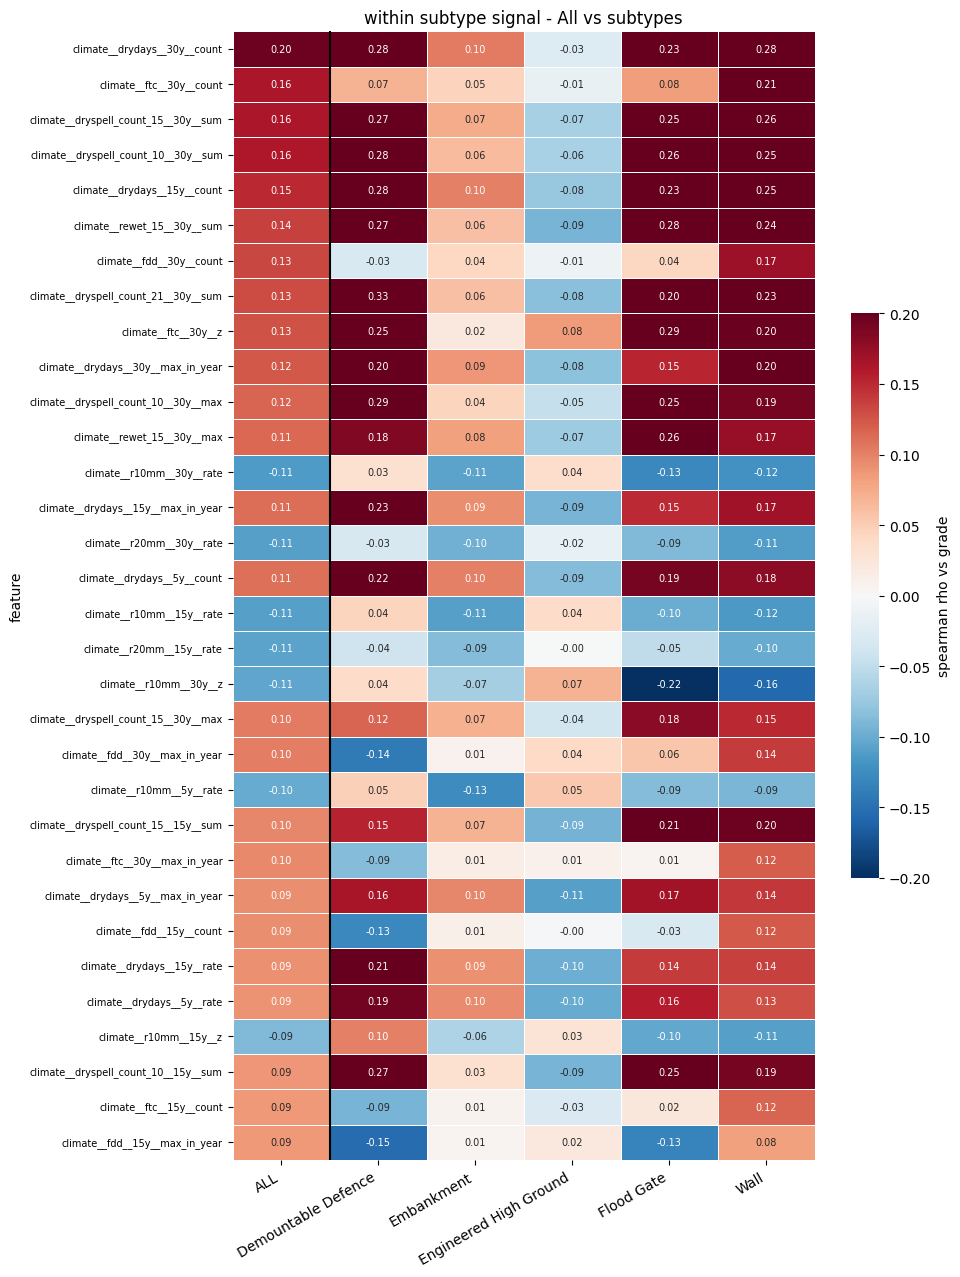

In [75]:


floor = 0.086 # using the value for geosure feature that I have decided is unimportant based on previous experiment results, rows below this on ALL are noise
top = mat.filter(pl.col("ALL").abs().ge(floor))
pdf = top.to_pandas().set_index("feature")[subtype_order]

plt.figure(figsize=(1.3 * len(subtype_order) + 2, 0.34 * len(pdf) + 2))
sns.heatmap(
    pdf, 
    vmin=-0.2, 
    vmax=0.2, 
    cmap="RdBu_r", 
    center=0, # scale to the data, not +/-1
    annot=True, 
    fmt=".2f", 
    annot_kws={"size": 7},
    linewidths=0.4, 
    cbar_kws={"label": "spearman rho vs grade", "shrink": 0.5},
)

plt.axvline(1, color="black", lw=1.5) # divide ALL from the within subtype panel
plt.title("within subtype signal - All vs subtypes")
plt.xticks(rotation=30, ha="right"); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

so this is both interesting and quite strange.

The motivation for looking for climate data and extracting features, and for the specific features that i thought of, was that they could related to specific weathering mechanisms. When I came up with them, I was really think mostly about soil weathering. For example, freeze thaw cycles, desiccation, shrinking and expanding cycles. But this ment that i expected to see predictive signal, if it existed at all, mostly predict grade in the assets made out of earth, ie. embankments and high ground. It turns out that these features seem to have stronger correlations with the target in the other three asset types - demountable defences, flood gates, and walls. This is interesting, but it also makes me somewhat skeptical of what exactly the encoded information in these.

one point to note is the asset types that are now showing stronger relationships are now the ones with the lower sample sizes, so numbers could be less trustworthy. Also, these are still weak relationships by absolute standards its worth remembering. 

In [77]:
# use mutual information to do the same thing
# instead of a linear correlation, should be able to catch non linear relationships to grade plus work when the signal isnt monotonic

from sklearn.feature_selection import mutual_info_classif


def mi_score(frame, feat, seeds=(0, 1, 2)):
    
    s = frame.select(feat, "condition_grade").drop_nulls()
    x = s[feat].to_numpy()
    y = s["condition_grade"].to_numpy().astype(int)

    if len(x) < 30 or np.unique(x).size < 2:
        return None
    
    vals = [
        mutual_info_classif(
            x.reshape(-1, 1), y, discrete_features=False, n_neighbors=3, random_state=sd
        )[0]
        for sd in seeds
    ]

    return {"feature": feat, "n_mi": len(x), "mi": float(np.mean(vals))}

climate_mi = [mi_score(joined, col) for col in columns]
geosure_mi = [mi_score(scope, col) for col in scope.columns if col.startswith("geosure")] # continue using this as a baseline for how much information a feature needs to be potentially useful


df_mi = pl.DataFrame(climate_mi)
mi_floor = max(row.get("mi") for row in geosure_mi) 


In [78]:
df_mi

feature,n_mi,mi
str,i64,f64
"""climate__ftc__2y__count""",23288,0.031927
"""climate__ftc__2y__rate""",23288,0.03593
"""climate__ftc__2y__max_in_year""",23203,0.016624
"""climate__ftc__2y__z""",23288,0.243565
"""climate__fdd__2y__count""",23288,0.217685
…,…,…
"""climate__dryspell_count_21__30…",23203,0.006597
"""climate__rewet_15__30y__sum""",23203,0.044132
"""climate__rewet_15__30y__mean""",23203,0.063643


In [79]:

print("geosure MI floor:", round(mi_floor, 5))

geosure MI floor: 0.00548


In [82]:
combined = (
    df_stats.join(df_mi.select("feature", "mi"), on="feature", how="left")
    .with_columns(
        (pl.col("mi") > mi_floor).alias("mi_above_floor"),
        (pl.col("rho").abs() < 0.086).alias("rho_below_floor"),
    )
)

with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=260):
    print("\n\ntop by MI:\n")
    print(
        combined.select(
            "feature", "n", "rho", "average_precision_increase", "decile_peak_lift", "mi", "mi_above_floor"
        ).sort("mi", descending=True).head(40))

    print("\n\nMI only signal: mi above floor and absolute rho below floor:\n")
    print(
        combined
            .filter(pl.col("mi_above_floor") & pl.col("rho_below_floor"))
            .select("feature", "n", "rho", "decile_peak_lift", "mi")
            .sort("mi", descending=True)
        )



top by MI:

shape: (40, 7)
┌─────────────────────────────────┬───────┬─────────┬────────────────────────────┬──────────────────┬──────────┬────────────────┐
│ feature                         ┆ n     ┆ rho     ┆ average_precision_increase ┆ decile_peak_lift ┆ mi       ┆ mi_above_floor │
│ ---                             ┆ ---   ┆ ---     ┆ ---                        ┆ ---              ┆ ---      ┆ ---            │
│ str                             ┆ i64   ┆ f64     ┆ f64                        ┆ f64              ┆ f64      ┆ bool           │
╞═════════════════════════════════╪═══════╪═════════╪════════════════════════════╪══════════════════╪══════════╪════════════════╡
│ null                            ┆ null  ┆ null    ┆ null                       ┆ null             ┆ null     ┆ null           │
│ climate__r10mm__2y__z           ┆ 23288 ┆ 0.0117  ┆ 0.9676                     ┆ 1.19652          ┆ 0.258108 ┆ true           │
│ climate__drydays__2y__z         ┆ 23288 ┆ 0.0293  ┆ 1.0971 

looks like way more features are clearing the mutual info floor than cleared the correlation floor, but i think this could be an artifact of the features containing more randomness. i think this is shown by the top columns all being continuous, with the discrete one (naturally have lower entropy because there is a finite set of allowed values) lower down. 

its interesting to see differences, but i don't think a real relationship between a feature and the target shows up in the mutual info table if it was completely absent from the corr and the average precision. So i think this is more likely to be a quirk of the type of data we have here than a sign that the features contain more signal than we thought that is non linear so not measured as well by the previous check. 

## notebook conclusions:

the headline is that i don't think there are any features here which are a clear, top teir candidate to become important in a good model. There are several that i'll identify to carry into modelling but i wouldn't be suprised if they all get stripped out again before the final model.

There could be some reason to create orthogonal componants from several of the features using PCA or NMF - particularly all the ones describing total moisture. 


the redundancy (heatmaps) structure reduces ~145 columns to ~3 axes: a temperature axis (ftc ≈ fdd), one moisture axis (drydays / dryspell / r10 / r20 / rain_max_day, dry-pole vs wet-pole), and the `z` variants which remove each cell's mean. so i carry one representative per axis, each in a `rate` (raw) and `z` (spatial-mean-removed) form, at the 30y window where any signal concentrated. the experiment can then test directly whether a metric helps only through its spatial mean (geography) or retains anything after 


carried forward:

    - `climate__drydays__30y__rate` - moisture axis, raw. strongest ALL pass signal, but Wall/Flood-Gate-localised, so expected to be geographic
    - `climate__drydays__30y__z` - moisture axis, spatial mean removed. tests whether any moisture signal survives de meaning.
    - `climate__ftc__30y__rate` - temperature axis, raw (age normalised)
    - `climate__ftc__30y__z` - temperature axis, de meaned. the one metric that retained signal after de meaning, though it sign flips across windows (suspicious) and carries a temporal/inspection-date confound (z is anomaly vs a fixed 1991–2020 baseline), so it is a candidate, not that promising in my opinion

definitively excluded:

    - `count` forms - covariate with `observable_years` and therefore asset age, that inflates `drydays__30y__count` (0.196) over its `rate` (which strips it), and age is already a base feature, so `rate` is the better form
    - heavy rain (`r10mm`/`r20mm`) - the inverted pole of the moisture axis, nearly redundant with `drydays`
    - short windows (2y/5y) - flat, weathering is cumulative so 30y is the mechanistically apt window anyway.
    - everything the redundancy heatmaps showed aliased (rewet ~= dryspell_count, count ≈ rate).

maybes:

if the blocked test shows the moisture columns do nothing individually but there's reason to think they act jointly, a PCA on the *`z`* moisture block (not the raw rates - PC1 of the rates is just the arid-ness gradient) is the first follow up. not leading with it, because a latent component is harder to interpret in SHAP and in the writeup than `drydays__30y`, and the likely outcome is null, i'd rather be able to describe plainly.

expected outcome: weak or null and geographic